In [ ]:
!git clone https://github.com/ibm-granite/granite-tsfm.git
%cd granite-tsfm
!pip install -e .

Cloning into 'granite-tsfm'...
remote: Enumerating objects: 14616, done.
remote: Counting objects: 100% (3080/3080), done.
remote: Compressing objects: 100% (446/446), done.
remote: Total 14616 (delta 2833), reused 2682 (delta 2624), pack-reused 11536 (from 2)
Receiving objects: 100% (14616/14616), 93.74 MiB | 34.71 MiB/s, done.
Resolving deltas: 100% (10017/10017), done.
/content/granite-tsfm
Obtaining file:///content/granite-tsfm
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 137.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 762.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip uninstall -y torchvision torchaudio


Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126


In [ ]:
import torch
print(torch.__version__)
print("CUDA:", torch.cuda.is_available())


2.8.0+cu128
CUDA: True


In [ ]:
%cd /content/granite-tsfm
!ls tsfm_public/models/tinytimemixer

from tsfm_public.models.tinytimemixer.modeling_tinytimemixer import TinyTimeMixerForPrediction
from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig

# Create a dummy configuration
config = TinyTimeMixerConfig(
    input_size=5,         # number of time series
    context_length=10,    # dummy context length
    prediction_length=3   # dummy target length
)

# Instantiate the model
model = TinyTimeMixerForPrediction(config)

print("TinyTimeMixerForPrediction instantiated ✅")




/content/granite-tsfm
configuration_tinytimemixer.py	modeling_tinytimemixer.py  utils
__init__.py			README.md
TinyTimeMixerForPrediction instantiated ✅


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch

# ---- Step 1: Load the latest FRED-MD CSV ----
fred = pd.read_csv("/content/FRED-MD_2024m12.csv", index_col=0)

# Convert index to datetime and drop invalid rows
fred.index = pd.to_datetime(fred.index, errors="coerce")
fred = fred.loc[fred.index.notna()]

# Fill missing values
fred = fred.ffill().bfill()

print("FRED-MD shape:", fred.shape)
print("Columns:", fred.columns[:10], "...")

# ---- Step 2: Define context and target windows ----
context_start = "2018-12-01"
context_end   = "2023-11-01"

target_start = "2023-12-01"
target_end   = "2024-11-01"

context_df = fred.loc[context_start:context_end]
target_df  = fred.loc[target_start:target_end]

print("Context shape:", context_df.shape)
print("Target shape:", target_df.shape)

# ---- Step 3: Standard scale ----
scaler = StandardScaler()
scaler.fit(context_df.values)  # fit only on context

context_scaled = scaler.transform(context_df.values)
target_scaled  = scaler.transform(target_df.values)

# ---- Step 4: Convert to PyTorch tensors ----
# shape = (num_series, time)
context_tensor = torch.tensor(context_scaled.T, dtype=torch.float32)
target_tensor  = torch.tensor(target_scaled.T, dtype=torch.float32)

print("Context tensor shape:", context_tensor.shape)
print("Target tensor shape:", target_tensor.shape)
print("Any NaNs left?", torch.isnan(context_tensor).any().item(), torch.isnan(target_tensor).any().item())

# ---- Optional: move to GPU ----
device = "cuda" if torch.cuda.is_available() else "cpu"
context_tensor = context_tensor.to(device)
target_tensor = target_tensor.to(device)
print("Tensors moved to", device)


FRED-MD shape: (791, 126)
Columns: Index(['RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO',
       'IPFPNSS', 'IPFINAL', 'IPCONGD', 'IPDCONGD'],
      dtype='object') ...
Context shape: (60, 126)
Target shape: (12, 126)
Context tensor shape: torch.Size([126, 60])
Target tensor shape: torch.Size([126, 12])
Any NaNs left? False False


/tmp/ipython-input-2801141688.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fred.index = pd.to_datetime(fred.index, errors="coerce")


Tensors moved to cuda


In [ ]:
from tsfm_public.models.tinytimemixer.modeling_tinytimemixer import TinyTimeMixerForPrediction
from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig
import torch.nn as nn
import torch.optim as optim
import torch

# ---- Step 6: Model config ----
config = TinyTimeMixerConfig(
    input_size=context_tensor.shape[0],      # number of time series, e.g., 126
    context_length=context_tensor.shape[1],  # should be 60 months
    prediction_length=target_tensor.shape[1] # e.g., 12 months
)

model = TinyTimeMixerForPrediction(config).to(device)
model.train()  # set to training mode

# ---- Step 7: Training setup ----
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 50  # small test run

# ---- Step 8: Minimal pretraining loop ----
for epoch in range(epochs):
    optimizer.zero_grad()

    # Add batch dim and transpose
    input_tensor = context_tensor.T.unsqueeze(0)  # (1, context_length, num_series)

    output = model(input_tensor)

    # Extract predictions
    pred_tensor = output.prediction_outputs[0].T  # (num_series, prediction_length)

    # Compute loss
    loss = criterion(pred_tensor, target_tensor)


    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")



Epoch 1/50, Loss: 1.899454
Epoch 2/50, Loss: 1.857939
Epoch 3/50, Loss: 1.795958
Epoch 4/50, Loss: 1.757304
Epoch 5/50, Loss: 1.721190
Epoch 6/50, Loss: 1.672345
Epoch 7/50, Loss: 1.648781
Epoch 8/50, Loss: 1.604507
Epoch 9/50, Loss: 1.597163
Epoch 10/50, Loss: 1.564665
Epoch 11/50, Loss: 1.534776
Epoch 12/50, Loss: 1.495528
Epoch 13/50, Loss: 1.465524
Epoch 14/50, Loss: 1.451855
Epoch 15/50, Loss: 1.438018
Epoch 16/50, Loss: 1.395923
Epoch 17/50, Loss: 1.380703
Epoch 18/50, Loss: 1.339595
Epoch 19/50, Loss: 1.315933
Epoch 20/50, Loss: 1.320464
Epoch 21/50, Loss: 1.273678
Epoch 22/50, Loss: 1.244367
Epoch 23/50, Loss: 1.217146
Epoch 24/50, Loss: 1.174923
Epoch 25/50, Loss: 1.159941
Epoch 26/50, Loss: 1.143514
Epoch 27/50, Loss: 1.105324
Epoch 28/50, Loss: 1.077631
Epoch 29/50, Loss: 1.059845
Epoch 30/50, Loss: 1.046054
Epoch 31/50, Loss: 1.021805
Epoch 32/50, Loss: 1.030051
Epoch 33/50, Loss: 0.964405
Epoch 34/50, Loss: 0.933636
Epoch 35/50, Loss: 0.899893
Epoch 36/50, Loss: 0.896999
E

In [ ]:
import torch
import torch.nn.functional as F

model.eval()  # VERY important

with torch.no_grad():
    # (1, 60, num_series)
    input_tensor = context_tensor.T.unsqueeze(0)

    output = model(input_tensor)

    # (num_series, 12)
    preds = output.prediction_outputs[0].T

# Metrics
mse = F.mse_loss(preds, target_tensor).item()
mae = F.l1_loss(preds, target_tensor).item()

print("📊 Pretrained Tiny Time Mixer (in-memory)")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")


📊 Pretrained Tiny Time Mixer (in-memory)
MSE: 0.552272
MAE: 0.555197


In [ ]:
from tsfm_public.models.tinytimemixer.modeling_tinytimemixer import TinyTimeMixerForPrediction
import torch
import torch.nn.functional as F

# Fresh random-init model (DO NOT TRAIN)
random_model = TinyTimeMixerForPrediction(config).to(device)
random_model.eval()

with torch.no_grad():
    input_tensor = context_tensor.T.unsqueeze(0)  # (1, 60, num_series)
    output_rand = random_model(input_tensor)

    # (num_series, 12)
    preds_rand = output_rand.prediction_outputs[0].T

# Metrics
rand_mse = F.mse_loss(preds_rand, target_tensor).item()
rand_mae = F.l1_loss(preds_rand, target_tensor).item()

print("📉 Random-init Tiny Time Mixer")
print(f"MSE: {rand_mse:.6f}")
print(f"MAE: {rand_mae:.6f}")


📉 Random-init Tiny Time Mixer
MSE: 1.826433
MAE: 1.126180


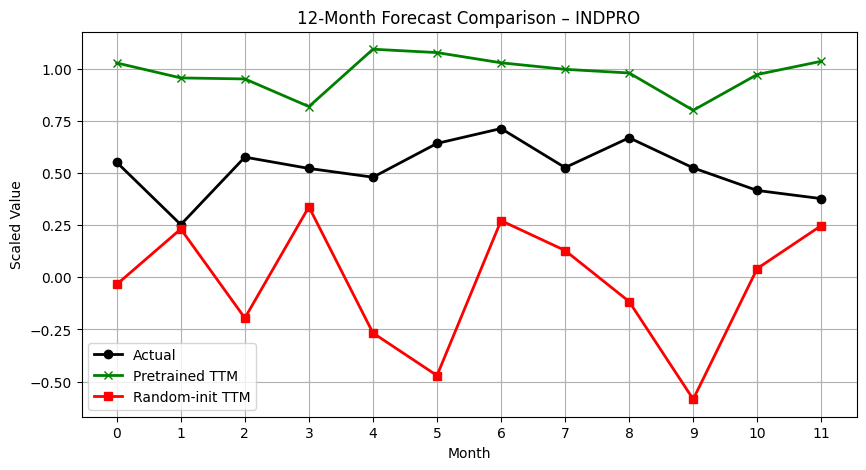

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tsfm_public.models.tinytimemixer.modeling_tinytimemixer import TinyTimeMixerForPrediction

# ---- Step 1: Make sure both models are in eval mode ----
model.eval()  # pretrained
random_model = TinyTimeMixerForPrediction(config).to(device)  # fresh random-init
random_model.eval()

with torch.no_grad():
    # ---- Step 2: Run both models on context window ----
    input_tensor = context_tensor.T.unsqueeze(0)  # (1, context_length, num_series)

    pretrained_output = model(input_tensor)
    random_output     = random_model(input_tensor)

# ---- Step 3: Choose indicator to plot ----
series_idx = fred.columns.get_loc("INDPRO")  # change to any series

# ---- Step 4: Extract series predictions ----
pretrained_preds = pretrained_output.prediction_outputs[0].T.cpu().numpy()  # (num_series, prediction_length)
random_preds     = random_output.prediction_outputs[0].T.cpu().numpy()
target_series    = target_tensor.cpu().numpy()

pretrained_series = pretrained_preds[series_idx]
random_series     = random_preds[series_idx]
actual_series     = target_series[series_idx]

# ---- Step 5: Plot ----
time_axis = range(len(actual_series))

plt.figure(figsize=(10,5))
plt.plot(time_axis, actual_series, marker='o', label="Actual", color='black', linewidth=2)
plt.plot(time_axis, pretrained_series, marker='x', label="Pretrained TTM", color='green', linewidth=2)
plt.plot(time_axis, random_series, marker='s', label="Random-init TTM", color='red', linewidth=2)
plt.title(f"12-Month Forecast Comparison – {fred.columns[series_idx]}")
plt.xlabel("Month")
plt.ylabel("Scaled Value")
plt.xticks(time_axis)
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
from tsfm_public.models.tinytimemixer.configuration_tinytimemixer import TinyTimeMixerConfig
from tsfm_public.models.tinytimemixer.modeling_tinytimemixer import TinyTimeMixerForPrediction
import torch.nn as nn
import torch.optim as optim
import torch

# ---- Step 1: New config with small change ----
config = TinyTimeMixerConfig(
    input_size=context_tensor.shape[0],
    context_length=context_tensor.shape[1],
    prediction_length=target_tensor.shape[1],
    d_model=128  # previously maybe 64
)

# ---- Step 2: Initialize model ----
model = TinyTimeMixerForPrediction(config).to(device)
model.train()

# ---- Step 3: Training setup ----
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 50  # small test run

# ---- Step 4: Pretraining loop ----
for epoch in range(epochs):
    optimizer.zero_grad()
    input_tensor = context_tensor.T.unsqueeze(0)
    output = model(input_tensor)
    preds = output.prediction_outputs[0].T
    loss = criterion(preds, target_tensor)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")


Epoch 1/50, Loss: 1.808841
Epoch 2/50, Loss: 1.747827
Epoch 3/50, Loss: 1.666274
Epoch 4/50, Loss: 1.587118
Epoch 5/50, Loss: 1.528797
Epoch 6/50, Loss: 1.467295
Epoch 7/50, Loss: 1.432263
Epoch 8/50, Loss: 1.383591
Epoch 9/50, Loss: 1.342704
Epoch 10/50, Loss: 1.280971
Epoch 11/50, Loss: 1.219485
Epoch 12/50, Loss: 1.193473
Epoch 13/50, Loss: 1.151792
Epoch 14/50, Loss: 1.090819
Epoch 15/50, Loss: 1.046191
Epoch 16/50, Loss: 0.990291
Epoch 17/50, Loss: 0.967527
Epoch 18/50, Loss: 0.972200
Epoch 19/50, Loss: 0.904501
Epoch 20/50, Loss: 0.938253
Epoch 21/50, Loss: 0.854844
Epoch 22/50, Loss: 0.840032
Epoch 23/50, Loss: 0.853211
Epoch 24/50, Loss: 0.779744
Epoch 25/50, Loss: 0.775880
Epoch 26/50, Loss: 0.779698
Epoch 27/50, Loss: 0.785431
Epoch 28/50, Loss: 0.730952
Epoch 29/50, Loss: 0.704962
Epoch 30/50, Loss: 0.721013
Epoch 31/50, Loss: 0.702228
Epoch 32/50, Loss: 0.672184
Epoch 33/50, Loss: 0.687669
Epoch 34/50, Loss: 0.639667
Epoch 35/50, Loss: 0.616576
Epoch 36/50, Loss: 0.591988
E

In [ ]:
import torch
import torch.nn.functional as F

# Make sure the model is in evaluation mode
model.eval()

with torch.no_grad():
    # Add batch dim and transpose: (1, context_length, num_series)
    input_tensor = context_tensor.T.unsqueeze(0)

    # Forward pass
    output = model(input_tensor)

    # Extract predictions: (num_series, prediction_length)
    preds = output.prediction_outputs[0].T

# Compute metrics
mse = F.mse_loss(preds, target_tensor).item()
mae = F.l1_loss(preds, target_tensor).item()

print("📊 Pretrained Tiny Time Mixer (modified architecture)")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")


📊 Pretrained Tiny Time Mixer (modified architecture)
MSE: 0.314932
MAE: 0.406156


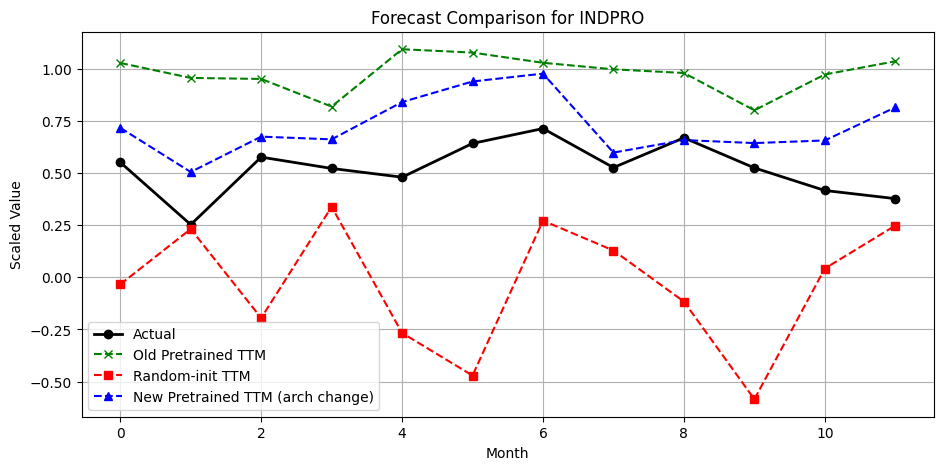

In [ ]:
import matplotlib.pyplot as plt

# ========== CONFIGURATION ==========
series_name = "INDPRO"  # <-- easily change this
series_idx  = fred.columns.get_loc(series_name)

# Map models to their outputs and colors
models_dict = {
    "Old Pretrained TTM": pretrained_output,
    "Random-init TTM": random_output,
    "New Pretrained TTM (arch change)": new_output
}
colors_dict = {
    "Old Pretrained TTM": "green",
    "Random-init TTM": "red",
    "New Pretrained TTM (arch change)": "blue"
}
markers_dict = {
    "Old Pretrained TTM": "x",
    "Random-init TTM": "s",
    "New Pretrained TTM (arch change)": "^"
}

# ========== DATA ==========
# Actual target series
target_series = target_tensor[series_idx].cpu().numpy()
time_axis     = range(len(target_series))

# ========== PLOT ==========
plt.figure(figsize=(11, 5))
plt.plot(time_axis, target_series, marker='o', label="Actual", color='black', linewidth=2)

for model_name, output in models_dict.items():
    preds = output.prediction_outputs[0].T[series_idx].cpu().numpy()
    plt.plot(
        time_axis,
        preds,
        marker=markers_dict[model_name],
        linestyle="--",
        color=colors_dict[model_name],
        label=model_name
    )

plt.title(f"Forecast Comparison for {series_name}")
plt.xlabel("Month")
plt.ylabel("Scaled Value")
plt.legend()
plt.grid(True)
plt.show()


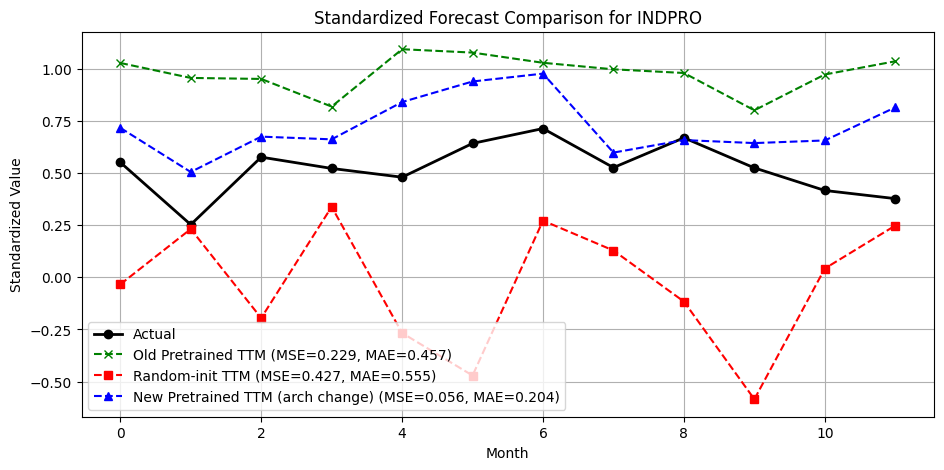

In [29]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ========== CONFIGURATION ==========
series_name = "INDPRO"  # <-- easily change this
series_idx  = fred.columns.get_loc(series_name)

# Map models to their outputs, colors, and markers
models_dict = {
    "Old Pretrained TTM": pretrained_output,
    "Random-init TTM": random_output,
    "New Pretrained TTM (arch change)": new_output
}
colors_dict = {
    "Old Pretrained TTM": "green",
    "Random-init TTM": "red",
    "New Pretrained TTM (arch change)": "blue"
}
markers_dict = {
    "Old Pretrained TTM": "x",
    "Random-init TTM": "s",
    "New Pretrained TTM (arch change)": "^"
}

# ========== DATA ==========
# Actual standardized target series
target_series = target_tensor[series_idx].cpu().numpy()
time_axis     = range(len(target_series))

# ========== PLOT ==========
plt.figure(figsize=(11, 5))
plt.plot(time_axis, target_series, marker='o', label="Actual", color='black', linewidth=2)

for model_name, output in models_dict.items():
    preds = output.prediction_outputs[0].T[series_idx].cpu().numpy()
    # Compute metrics
    mse = F.mse_loss(torch.tensor(preds), torch.tensor(target_series)).item()
    mae = F.l1_loss(torch.tensor(preds), torch.tensor(target_series)).item()

    # Plot
    plt.plot(
        time_axis,
        preds,
        marker=markers_dict[model_name],
        linestyle="--",
        color=colors_dict[model_name],
        label=f"{model_name} (MSE={mse:.3f}, MAE={mae:.3f})"
    )

plt.title(f"Standardized Forecast Comparison for {series_name}")
plt.xlabel("Month")
plt.ylabel("Standardized Value")
plt.legend()
plt.grid(True)
plt.show()


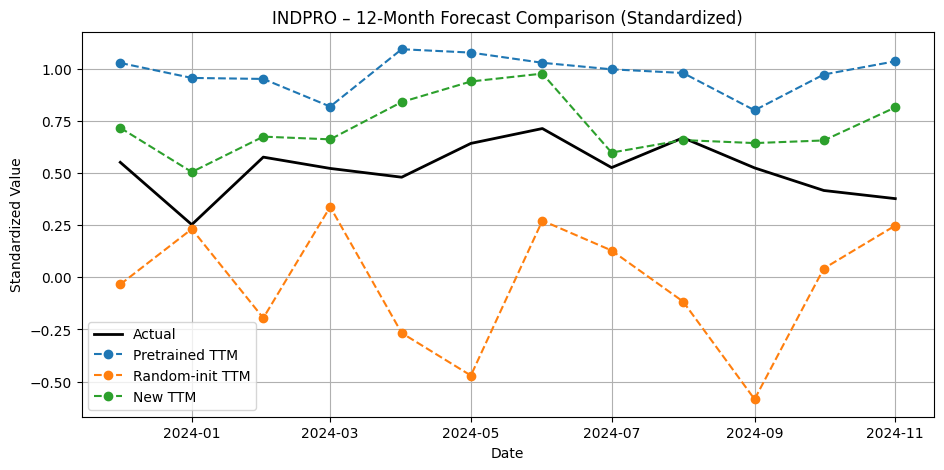

In [31]:
import matplotlib.pyplot as plt
import torch

# ========= Forecast Plot (change series_id only) =========
series_id = "INDPRO"  # <-- easily change

# Actual standardized values (target window)
actual = target_tensor[fred.columns.get_loc(series_id)].cpu().numpy()
time_index = pd.date_range(start="2023-12-01", periods=len(actual), freq="MS")

plt.figure(figsize=(11, 5))
plt.plot(time_index, actual, label="Actual", linewidth=2, color="black")

# Dictionary of models and outputs
model_outputs = {
    "Pretrained TTM": pretrained_output,
    "Random-init TTM": random_output,
    "New TTM": new_output,
}

for model_name, output in model_outputs.items():
    # Extract standardized predictions for the series
    preds = output.prediction_outputs[0].T[fred.columns.get_loc(series_id)].cpu().numpy()

    plt.plot(
        time_index,
        preds,
        linestyle="--",
        marker="o",
        label=model_name
    )

plt.title(f"{series_id} – 12-Month Forecast Comparison (Standardized)")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend()
plt.grid(True)
plt.show()
